# Color Histogram CBIR

This notebook implements a Content-Based Image Retrieval (CBIR) system
using color histogram features.

Steps:
- Load processed dataset
- Extract color histogram features
- Build feature database
- Compare query image with dataset images
- Retrieve top similar images

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

In [4]:
DATASET_PATH = "processed_dataset"

categories = sorted(os.listdir(DATASET_PATH))
print("Categories:", categories)

Categories: ['ambulance', 'bicycle', 'bus', 'car', 'fire_truck', 'motorcycle', 'tractor', 'truck', 'van']


## Feature Extraction Function

A color histogram describes the color distribution of an image.
Here, we use RGB channels and normalize the histogram.

In [5]:
def extract_color_histogram(image_path, bins=(8, 8, 8)):
    """
    Extract normalized color histogram from an image.
    
    Parameters:
        image_path : str
            Path to input image
        bins : tuple
            Number of bins for RGB channels
            
    Returns:
        hist : numpy array
            Flattened normalized histogram
    """
    image = cv2.imread(image_path)
    
    if image is None:
        return None
    
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    # 3D histogram for RGB channels
    hist = cv2.calcHist([image], [0, 1, 2], None, bins,
                        [0, 256, 0, 256, 0, 256])
    
    # Normalize histogram
    hist = cv2.normalize(hist, hist).flatten()
    
    return hist

## Build Feature Database

For each image in the dataset:
- extract histogram feature
- store image path
- store category label

In [6]:
image_paths = []
image_labels = []
features = []

for category in categories:
    category_path = os.path.join(DATASET_PATH, category)
    
    for img_name in os.listdir(category_path):
        img_path = os.path.join(category_path, img_name)
        hist = extract_color_histogram(img_path)
        
        if hist is not None:
            image_paths.append(img_path)
            image_labels.append(category)
            features.append(hist)

features = np.array(features)

print("Total images indexed:", len(image_paths))
print("Feature shape:", features.shape)

Total images indexed: 1800
Feature shape: (1800, 512)


## Similarity Function

We compare the query image with all dataset images using cosine similarity.
Higher score means more similar.

In [7]:
def retrieve_similar_images(query_image_path, top_k=5):
    query_feature = extract_color_histogram(query_image_path)
    
    if query_feature is None:
        print("Query image could not be loaded.")
        return []
    
    similarities = cosine_similarity([query_feature], features)[0]
    
    # Sort from highest similarity to lowest
    sorted_indices = np.argsort(similarities)[::-1]
    
    results = []
    for idx in sorted_indices:
        # Skip the query image itself
        if image_paths[idx] == query_image_path:
            continue
        
        results.append({
            "image_path": image_paths[idx],
            "label": image_labels[idx],
            "score": similarities[idx]
        })
        
        if len(results) == top_k:
            break
    
    return results

## Test with a Query Image

Choose one image from the dataset as the query image.

In [8]:
# query_image = "processed_dataset/beaches/100.jpg"  # manual change file path to pick image

# auto-pick image
category_path = "processed_dataset/car"
img_name = os.listdir(category_path)[3] # change the number to change file from 0 - 99

query_image = os.path.join(category_path, img_name)

print("Using:", query_image)

results = retrieve_similar_images(query_image, top_k=5)

for i, result in enumerate(results, 1):
    print(f"Rank {i}: {result['label']} | Score = {result['score']:.4f}")

Using: processed_dataset/car\1025.jpg
Rank 1: car | Score = 1.0000
Rank 2: car | Score = 0.9493
Rank 3: bicycle | Score = 0.9406
Rank 4: bicycle | Score = 0.9397
Rank 5: ambulance | Score = 0.9383


## Display Query Image and Retrieved Results

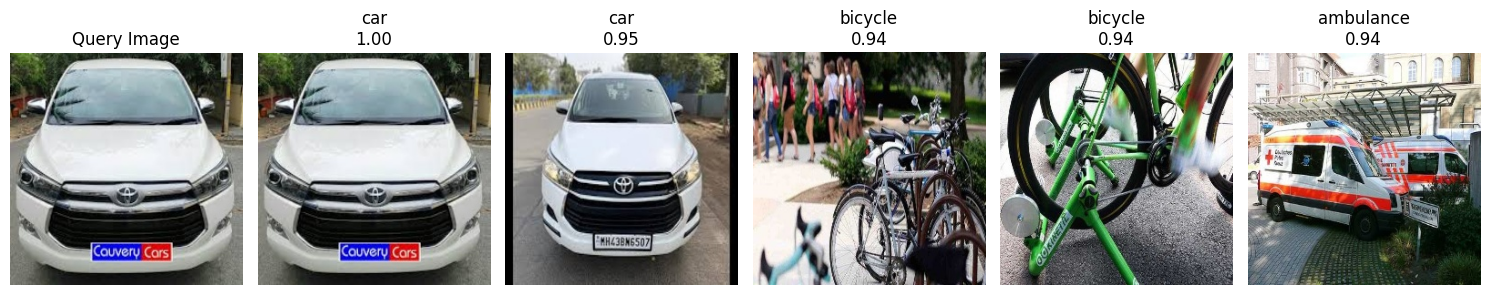

In [9]:
def display_results(query_image_path, results):
    plt.figure(figsize=(15, 4))
    
    # Show query image
    query_img = cv2.imread(query_image_path)
    query_img = cv2.cvtColor(query_img, cv2.COLOR_BGR2RGB)
    
    plt.subplot(1, len(results) + 1, 1)
    plt.imshow(query_img)
    plt.title("Query Image")
    plt.axis("off")
    
    # Show retrieved images
    for i, result in enumerate(results, start=2):
        img = cv2.imread(result["image_path"])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        plt.subplot(1, len(results) + 1, i)
        plt.imshow(img)
        plt.title(f"{result['label']}\n{result['score']:.2f}")
        plt.axis("off")
    
    plt.tight_layout()
    plt.show()

display_results(query_image, results)

## Try Other Query Images

You can test different categories by changing the query image path.
Examples:
- processed_dataset/flowers/10.jpg
- processed_dataset/buses/25.jpg
- processed_dataset/dinosaurs/50.jpg

Using: processed_dataset/bus\04d1869b-ad87-4838-a5f2-85c6ae329be0.jpg


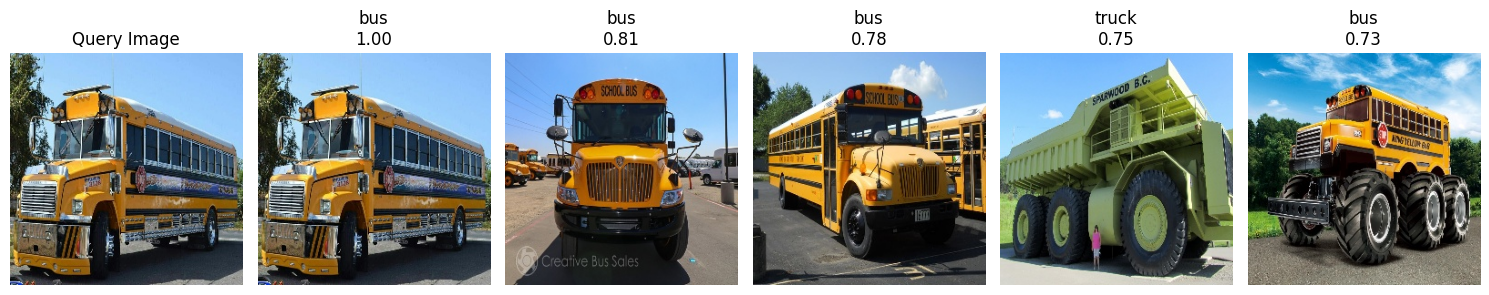

In [10]:
# auto-pick image
category_path = "processed_dataset/bus"
img_name = os.listdir(category_path)[0] # change the number to change file from 0 - 99

query_image = os.path.join(category_path, img_name)

print("Using:", query_image)

results = retrieve_similar_images(query_image, top_k=5)
display_results(query_image, results)

## Precision@5

In [11]:
def precision_at_k(query_image_path, results, k=5):
    query_label = os.path.basename(os.path.dirname(query_image_path))
    correct = sum(1 for r in results[:k] if r["label"] == query_label)
    return correct / k

# auto-pick image
category_path = "processed_dataset/car"
img_name = os.listdir(category_path)[3] # change the number to change file from 0 - 99

query_image = os.path.join(category_path, img_name)

print("Using:", query_image)
results = retrieve_similar_images(query_image, top_k=5)

p_at_5 = precision_at_k(query_image, results, k=5)
print(f"Precision@5: {p_at_5:.2f}")

Using: processed_dataset/car\1025.jpg
Precision@5: 0.40


## Summary

This notebook builds a basic CBIR system using color histogram features.
It works well for categories with strong color patterns such as:
- beaches
- flowers
- food

However, it may be weaker for categories with similar color distributions
but different object shapes.